In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from scipy import stats
from sklearn.model_selection import train_test_split
import warnings
import matplotlib.pyplot as plt
import datetime

In [3]:
pd.set_option('display.max_rows', 99999)
pd.set_option('display.max_columns', 500)
warnings.filterwarnings("ignore")

In [4]:
epc_49 = pd.read_csv('epc_encoded.csv')
##epc_encoded from previous step(preprocessing)
epc_49.shape

(54495, 94)

In [5]:
epc_49.head(1)

,Unnamed: 0,Total floor area (m²),Total current energy costs over 3 years (£),Current energy efficiency rating band,Current heating costs over 3 years (£),Current hot water costs over 3 years (£),Current lighting costs over 3 years (£),Part 1 Construction Age Band,Part 1 Floor 0 Room Height,Fixed Lighting Outlets Count,Low Energy Lighting Outlets Count,Low Energy Lighting %,Glazed Area,Habitable Room Count,Heated Room Count,Mechanical Ventilation,Meter Type,Solar Water Heating,Tenure,Transaction Type,Property Type,insulated_wall,insulated_roof,insulated_floor,wall_type,roof_type,floor_type,windows_glazing,MHS_boiler,MHS_radiators,MHS_electric heaters,MHS_heat pump,MHS_room heaters,MHS_community scheme,MHS_underfloor heating,MHS_warm air,MMH_mains gas,MHS_None,MHS_electric,MHS_oil,MHS_underfloor heating,MHS_lpg,MHS_dual fuel mineral and wood,MHS_wood pellets_logs,other,MHS_coal,MHS_other,MHCS_programmer,MHCS_time and temperature zone control,MHCS_manual charge control,MHCS_room thermostat(s),MHCS_appliance thermostats,MHCS_controls for high heat retention storage heaters,MHCS_automatic charge control,MHCS_charging system linked to use of community heating,MHCS_flat rate charging,MHCS_trvs,MHCS_bypass,MHCS_none,MHCS_no time or thermostatic control of room temperature,MHCS_other,MHCS_boiler energy manager,hws_from main system,hws_from secondary system,hws_community scheme,hws_electric immersion,hws_electric instantaneous at point of use,hws_heat pump,hws_gas multipoint,hws_gas instantaneous at point of use,hws_other,hws_None,hws_off-peak,hws_no cylinder thermostat,hws_standard tariff,hws_flue gas heat recovery,hws_plus solar,hws_waste water heat recovery,low_lighting,SH_room heaters,SH_none,SH_electric,SH_mains gas,SH_portable electric heaters,SH_dual fuel mineral and wood,SH_wood logs,SH_coal,SH_lpg,SH_wood pellets,SH_smokeless fuel,SH_anthracite,SH_bioethanol,SH_oil,built_form
0,0,45.0,3771.0,4,2478.0,1176.0,117.0,10,3.1,6.0,6.0,100.0,1.0,2.0,2.0,2,2,0,0,7,1,0,1,0,5,1,4,0,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,2,False,True,False,False,False,False,False,False,False,False,False,False,False,False,1


In [6]:
df_x = epc_49.drop(['Current energy efficiency rating band'], axis = 1)
def drop_correlated_features(dataframe, threshold):
    '''remove correlated features'''
    
    corr_matrix = dataframe.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(np.bool))
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    dataframe = dataframe.drop(to_drop, axis=1)
    print('Removed Columns {}'.format(to_drop))
    return dataframe

epc = drop_correlated_features(df_x,0.6)
epc['Current energy efficiency rating band']= epc_49['Current energy efficiency rating band']

Removed Columns ['Current heating costs over 3 years (£)', 'Current lighting costs over 3 years (£)', 'Fixed Lighting Outlets Count', 'Low Energy Lighting Outlets Count', 'Habitable Room Count', 'Heated Room Count', 'MHS_boiler', 'MHS_electric', 'MHCS_time and temperature zone control', 'MHCS_appliance thermostats', 'MHCS_charging system linked to use of community heating', 'MHCS_flat rate charging', 'MHCS_trvs', 'hws_from main system', 'hws_community scheme', 'hws_electric immersion', 'hws_off-peak', 'hws_plus solar', 'SH_none', 'SH_electric']


In [7]:
epc.head(2)

,Unnamed: 0,Total floor area (m²),Total current energy costs over 3 years (£),Current hot water costs over 3 years (£),Part 1 Construction Age Band,Part 1 Floor 0 Room Height,Low Energy Lighting %,Glazed Area,Mechanical Ventilation,Meter Type,Solar Water Heating,Tenure,Transaction Type,Property Type,insulated_wall,insulated_roof,insulated_floor,wall_type,roof_type,floor_type,windows_glazing,MHS_radiators,MHS_electric heaters,MHS_heat pump,MHS_room heaters,MHS_community scheme,MHS_underfloor heating,MHS_warm air,MMH_mains gas,MHS_None,MHS_oil,MHS_underfloor heating,MHS_lpg,MHS_dual fuel mineral and wood,MHS_wood pellets_logs,other,MHS_coal,MHS_other,MHCS_programmer,MHCS_manual charge control,MHCS_room thermostat(s),MHCS_controls for high heat retention storage heaters,MHCS_automatic charge control,MHCS_bypass,MHCS_none,MHCS_no time or thermostatic control of room temperature,MHCS_other,MHCS_boiler energy manager,hws_from secondary system,hws_electric instantaneous at point of use,hws_heat pump,hws_gas multipoint,hws_gas instantaneous at point of use,hws_other,hws_None,hws_no cylinder thermostat,hws_standard tariff,hws_flue gas heat recovery,hws_waste water heat recovery,low_lighting,SH_room heaters,SH_mains gas,SH_portable electric heaters,SH_dual fuel mineral and wood,SH_wood logs,SH_coal,SH_lpg,SH_wood pellets,SH_smokeless fuel,SH_anthracite,SH_bioethanol,SH_oil,built_form,Current energy efficiency rating band
0,0,45.0,3771.0,1176.0,10,3.1,100.0,1.0,2,2,0,0,7,1,0,1,0,5,1,4,0,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,2,False,False,False,False,False,False,False,False,False,False,False,False,1,4
1,1,143.0,2793.0,375.0,8,2.4,100.0,1.0,2,0,0,0,4,2,1,1,1,1,1,1,0,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,2,False,False,False,False,False,False,False,False,False,False,False,False,0,2


In [8]:
epc['Current energy efficiency rating band'].value_counts()

2    24296
3    14264
1     8682
4     4703
5     1454
0      688
6      408
Name: Current energy efficiency rating band, dtype: int64

In [9]:
epc.shape

(54495, 74)

In [10]:
# # Dataset sampling for faster computation
# epc = epc.groupby('Current energy efficiency rating band', group_keys=False).apply(lambda x: x.sample(frac=0.6))

In [11]:
# epc['Current energy efficiency rating band'].value_counts()

In [12]:
epc = epc.drop('Unnamed: 0', axis=1)

In [13]:
y = epc['Current energy efficiency rating band']
X = epc.drop(['Current energy efficiency rating band'], axis = 1)
X_train, X_test, y_train, y_test = train_test_split(X, y,random_state=40,  test_size=0.3)

In [14]:
# #==========Mutual info=======#
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import mutual_info_classif
#No we Will select the top 20 important features
sel_cols = SelectKBest(mutual_info_classif, k=20)
sel_cols.fit(X, y)
X.columns[sel_cols.get_support()]

TypeError: '<' not supported between instances of 'SelectKBest' and 'SelectKBest'

In [ ]:
epc_df =epc[['Total floor area (m²)', 'Total current energy costs over 3 years (£)',
       'Current hot water costs over 3 years (£)',
       'Part 1 Construction Age Band', 'Part 1 Floor 0 Room Height',
       'Low Energy Lighting %', 'Mechanical Ventilation', 'Tenure',
       'Transaction Type', 'Property Type', 'insulated_wall', 'insulated_roof',
       'wall_type', 'roof_type', 'floor_type', 'windows_glazing',
       'MMH_mains gas', 'MHCS_programmer', 'low_lighting', 'SH_room heaters', 'Current energy efficiency rating band']]

In [ ]:
def make_mi_scores(X, y):
    mi_scores = mutual_info_classif(X, y)
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores
mi_scores = make_mi_scores(X, y)
mi_scores[::3]  # show a few features with their MI scores

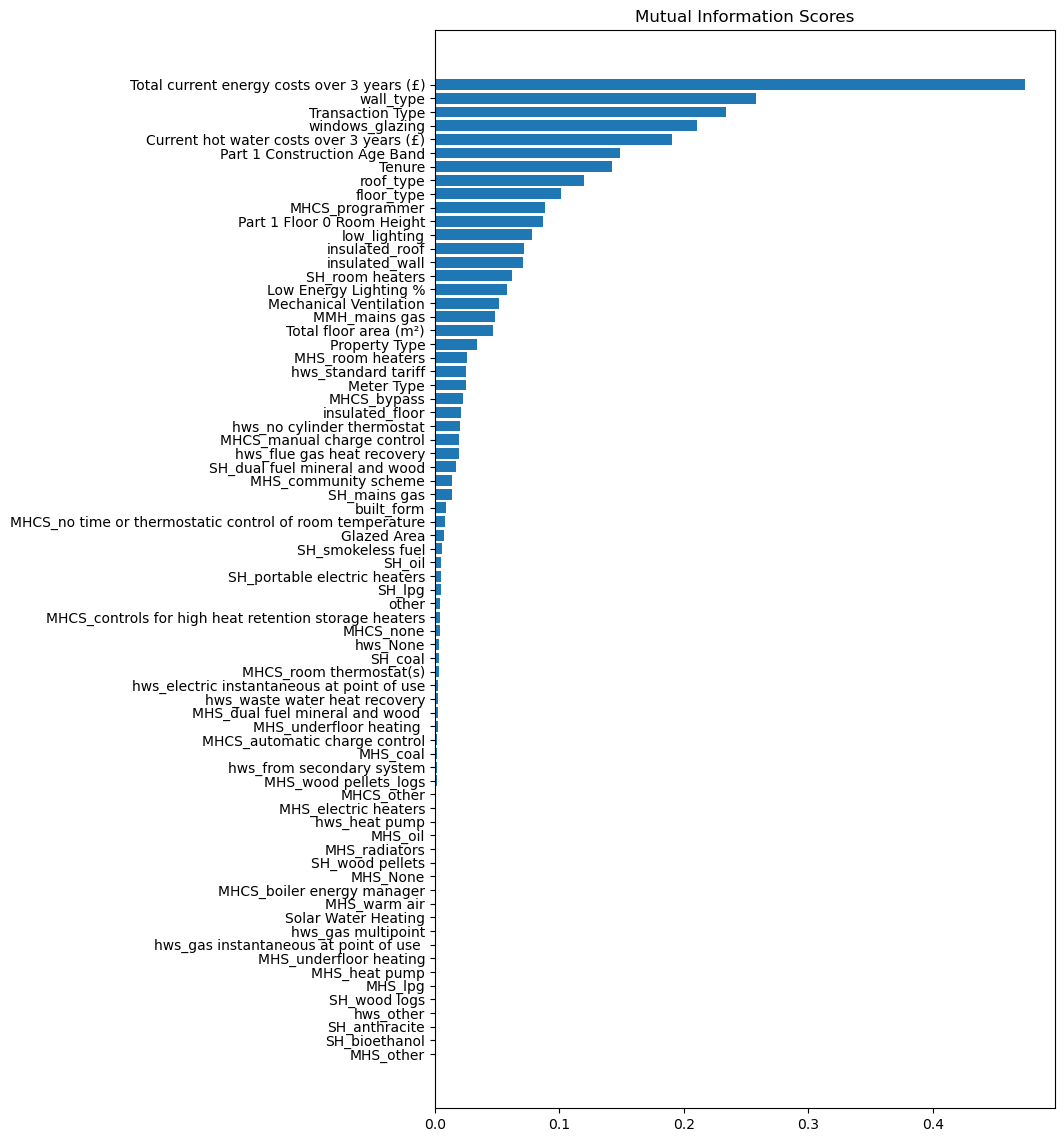

In [102]:
def plot_mi_scores(scores):
    scores = scores.sort_values(ascending=True)
    width = np.arange(len(scores))
    ticks = list(scores.index)
    plt.barh(width, scores)
    plt.yticks(width, ticks)
    plt.title("Mutual Information Scores")
plt.figure(dpi=100, figsize=(8, 14))
plot_mi_scores(mi_scores)

In [106]:
epc_df.to_csv('epc_best20.csv')  

In [104]:
epc_best20.head(10)

,Total floor area (m²),Total current energy costs over 3 years (£),Current hot water costs over 3 years (£),Part 1 Construction Age Band,Part 1 Floor 0 Room Height,Low Energy Lighting %,Mechanical Ventilation,Tenure,Transaction Type,Property Type,insulated_wall,insulated_roof,wall_type,roof_type,floor_type,windows_glazing,MMH_mains gas,MHCS_programmer,low_lighting,SH_room heaters,Current energy efficiency rating band
0,45.0,3771.0,1176.0,10,3.10,100.0,2,0,7,1,0,1,5,1,4,0,False,True,2,False,4
1,143.0,2793.0,375.0,8,2.40,100.0,2,0,4,2,1,1,1,1,1,0,True,True,2,False,2
2,65.0,1947.0,441.0,10,2.45,100.0,2,0,4,1,0,1,5,4,0,4,True,True,2,False,2
3,49.0,1158.0,195.0,7,2.40,100.0,2,1,7,1,1,1,1,4,1,0,True,True,2,False,2
4,212.0,6477.0,819.0,10,2.80,64.0,2,0,4,2,1,1,3,1,0,0,False,True,7,True,4
5,247.0,10329.0,324.0,10,3.10,84.0,2,0,4,2,0,1,3,1,1,0,True,True,9,False,4
6,86.0,2271.0,285.0,10,2.40,55.0,2,0,4,2,0,1,5,0,1,0,True,True,7,False,2
7,63.0,4155.0,1533.0,10,2.56,100.0,2,2,8,0,1,1,1,0,0,0,False,True,2,False,4
8,154.0,5301.0,327.0,10,3.15,100.0,2,1,8,1,0,0,5,1,4,4,True,True,2,False,4
9,96.0,2757.0,234.0,2,2.40,75.0,2,0,4,2,0,1,1,1,0,0,True,True,9,False,3


In [105]:
epc_best20.shape

(54495, 21)